Laborator 8 - Wine Dataset -
Arbori de Decizie


1. încărcarea datasetului

In [1]:
from sklearn.datasets import load_wine
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_wine()

2.  primele 5 rânduri

In [2]:
df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


3. feature names


In [3]:
print("Caracteristici:", data.feature_names)

Caracteristici: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


4. antrenarea unui arbore de decizie

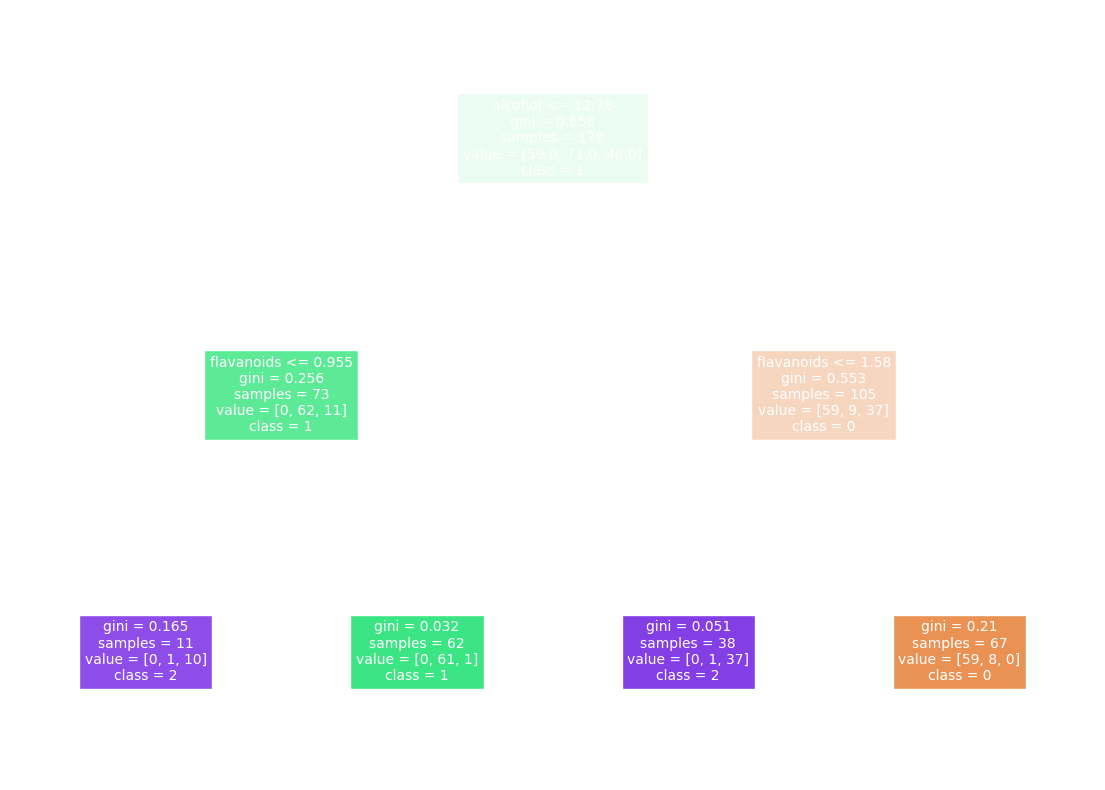

Primul nod verifica conditia alcohol <= 12.78.
Daca conditia este adevarata, se merge în stanga.
Daca este falsa, se merge în dreapta.
Al doilea nivel verifica valoarea flavanoids.


In [4]:
X = df[['alcohol', 'flavanoids']]

y = df['target']

model = DecisionTreeClassifier(max_depth=2)

model.fit(X, y)

plt.figure(figsize=(14,10), facecolor='white')

plot_tree(
    model,
    feature_names=['alcohol', 'flavanoids'],
    class_names=['0', '1', '2'],
    filled=True,
    fontsize=10
)

plt.show()

print("Primul nod verifica conditia alcohol <= 12.78.")
print("Daca conditia este adevarata, se merge în stanga.")
print("Daca este falsa, se merge în dreapta.")
print("Al doilea nivel verifica valoarea flavanoids.")

5. acuratețea pe setul de testare


In [24]:
X = df.drop('target', axis=1)

y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

model = DecisionTreeClassifier(max_depth=None)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Acuratete:", acc)

Acuratete: 0.9444444444444444


6. antrenarea unui model pe toate cele 13 caracteristici

In [22]:
X = df.drop('target', axis=1)

y = df['target']

model = DecisionTreeClassifier(random_state=42)

model.fit(X, y)

importances = model.feature_importances_

for feature, importance in zip(X.columns, importances):
    print(feature, ":", importance)

print("Caracteristicile care influenteaza cel mai mult deciziile arborelui sunt proline, od280/od315_of_diluted_wines si flavanoids, deoarece au cele mai mari valori ale importantei. Caracteristicile cu importanta 0 nu au fost folosite în clasificare.")

alcohol : 0.04727507393151268
malic_acid : 0.0
ash : 0.0
alcalinity_of_ash : 0.0
magnesium : 0.0329784450464887
total_phenols : 0.0
flavanoids : 0.1414466773122087
nonflavanoid_phenols : 0.0
proanthocyanins : 0.0
color_intensity : 0.0
hue : 0.0837867790622859
od280/od315_of_diluted_wines : 0.3120425747831769
proline : 0.38247044986432716
Caracteristicile care influenteaza cel mai mult deciziile arborelui sunt proline, od280/od315_of_diluted_wines si flavanoids, deoarece au cele mai mari valori ale importantei. Caracteristicile cu importanta 0 nu au fost folosite în clasificare.
